In [20]:
#This second test uses voltage values for the plots instead of collected energies. This uses the ESR to generate a proper value for the collected voltage. 

#All of the imports
import sionna.rt
%matplotlib notebook
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math
import drjit as dr
import mitsuba as mi
from typing import Tuple, List
import random 

from sionna.rt.utils import watt_to_dbm

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

from tabulate import tabulate

#Where all the constants RF harvesting functions, and custom display functions are stored
import radio_functions

#Animation
import matplotlib.animation as animation

import matplotlib as mpl

#GPS and time
import gpxpy
import gpxpy.gpx
import csv 
import datetime

using_preview = True

c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


| Type   |   Recieved Power (dbm) |   DC energy (dbm) | time (s)   |
|--------+------------------------+-------------------+------------|
| Mean   |               -37.8067 |              -140 |            |
| Q1     |               -42.7691 |              -140 |            |
| Median |               -36.9427 |              -140 |            |
| Q3     |               -31.1162 |              -140 |            |


| Not enough RF   | Charging   | Saturation   |
|-----------------+------------+--------------|
| 80.555%         | 19.445%    | 0.000%       |


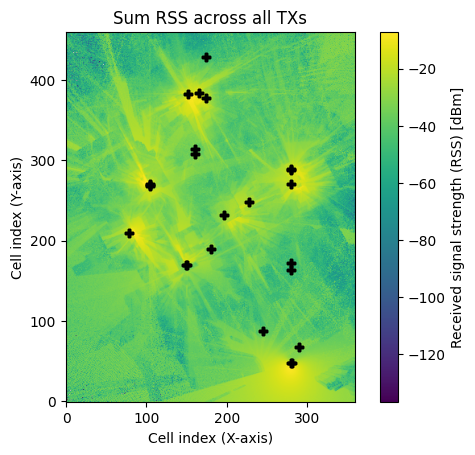

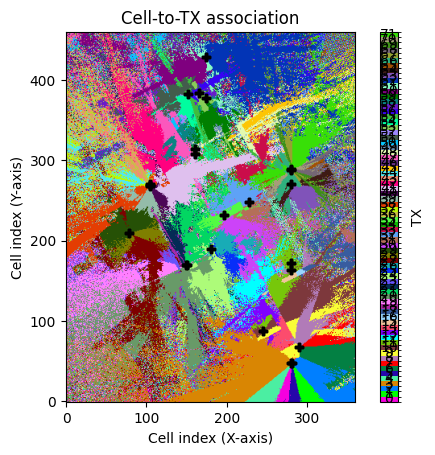

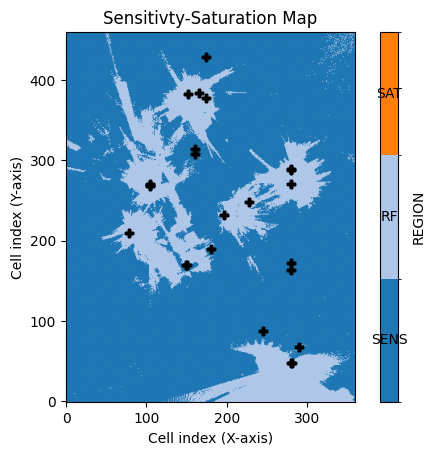

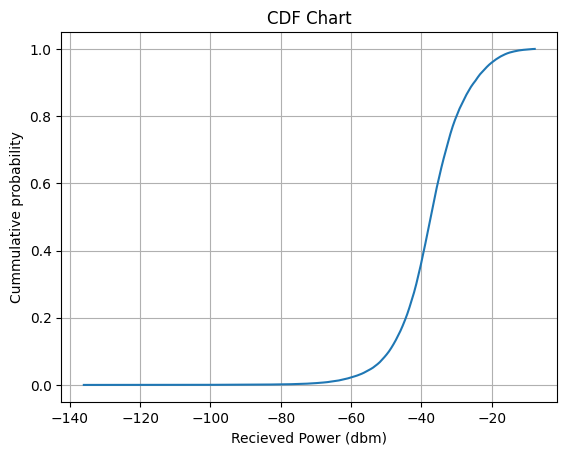

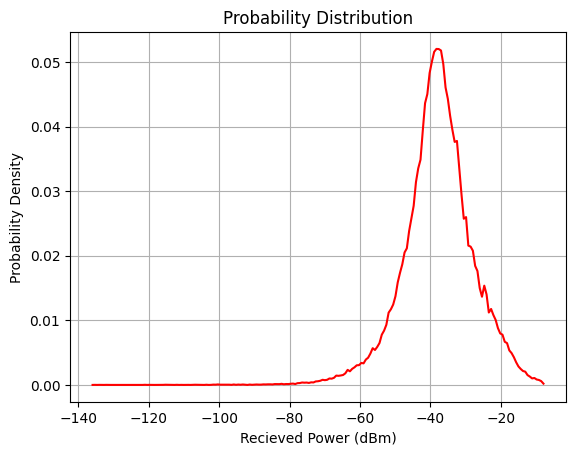

In [21]:
current_scene = load_scene("Blender2/UBC.xml")

current_scene.frequency = 1.0001e9
num_cols = 1
current_scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=num_cols, 
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="VH")

current_scene.rx_array = PlanarArray(num_rows=1,
                             num_cols=1, 
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",
                             polarization="VH")


transmitters = []


positions_array = []

positions_array = [
    [500, -900, 27],
    [505, -900, 27],
    [550, -800, 27],
    [325, -700, 27],
    [500, -320, 27],
    [500, -280, 27],


    [-150, -290, 40],
    [-155, -290, 40],
    [0, -190, 20],
    [-510, -90, 27],
    [80, 20, 33],
    [240, 100, 27],


    [-380, 200, 27],
    [-380, 205, 27],
    [-380, 210, 27],
    [-100, 400, 30],
    [-100, 430, 30],
    [-70, 780, 30],


    [-140, 770, 30],
    [-30, 750, 30],
    [-30, 1000, 30],
    [500, 210, 27],
    [500, 300, 27], 
    [500, 305, 27]
]

powers_array = [46, 49, 0, 0, 0, 0, 
                
                46, 46, 0, 49.8, 46.8, 0, 
                
                43, 40, 49.8, 0, 0, 49.8, 
                
                49.8, 40, 0, 49.8, 43, 40]

for i,_position in enumerate(positions_array):
    transmitters.append(Transmitter(name=f"tx{i}_1", position=_position, display_radius=10, power_dbm=powers_array[i]))
    first_angle = random.random()*360.0
    transmitters[-1].orientation = (first_angle, 0, 0)
    current_scene.add(transmitters[-1])

    transmitters.append(Transmitter(name=f"tx{i}_2", position=_position, display_radius=10, power_dbm=powers_array[i]))
    transmitters[-1].orientation = (first_angle+120, 0, 0)
    current_scene.add(transmitters[-1])

    transmitters.append(Transmitter(name=f"tx{i}_3", position=_position, display_radius=10, power_dbm=powers_array[i]))
    transmitters[-1].orientation = (first_angle+240, 0, 0)
    current_scene.add(transmitters[-1])
    
rm_solver = RadioMapSolver()
rm = rm_solver(current_scene,
               max_depth=30,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(5, 5),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1800, 2300],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical


cdf_values = radio_functions.sum_cdf(rm, metric="rss");
metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
metrics.print_related_values()

radio_functions.show_sum(rm, metric="rss")
radio_functions.show_association_more_colours(rm)
radio_functions.show_DC_regions(rm, metric="rss")


metrics.display_cdf_and_pdf(cdf_values[2])
current_scene.preview(radio_map=rm);

In [22]:
#Function to get cell position from lattitude and longitude 
def cell_from_lat_long(lat, long):
    return [int(-4.099942947 * lat + 14517.97912 * long + 1789705.009), int(22320.96592 * lat + -5.268575791 * long + -1100017.169)]

#Function to find the nearest time from the list of times
def nearest(items, pivot):
    nearest = min(items, key=lambda x: abs(x - pivot))
    timedelta = abs(nearest - pivot)
    return nearest, timedelta

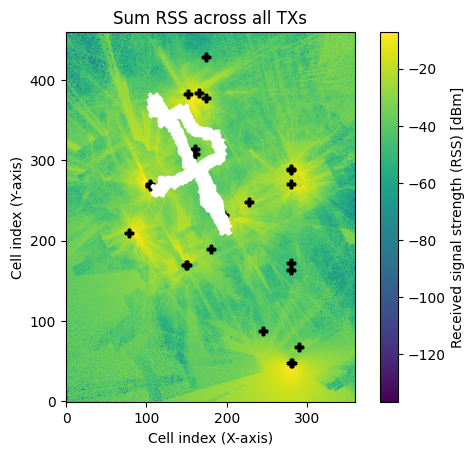

In [23]:
#Create GPS array
position_time_dict = {}

gpx_file = open(r'C:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\Measurements_data_2\gps_data\gps_data_day_1.gpx', 'r')
gpx_data = gpxpy.parse(gpx_file)


i = 0

for track in gpx_data.tracks:
    for segment in track.segments:
        for point in segment.points:
            cell_pos = cell_from_lat_long(point.latitude, point.longitude)
            position_time_dict[point.time] = cell_pos

            position = mi.Point3f([cell_pos[0], cell_pos[1], 1])
            position *= 5
            position -= mi.Point3f([700, 1050, 0]) #Center at middle of array
            position += mi.Point3f([0, 10, 0]) #Add offset of radio_map

            current_scene.add(Receiver(name=f"rx_{i}", position = position))
            i+=1
            sample_date_time = point.time

rm = rm_solver(current_scene,
               max_depth=30,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(5, 5),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1800, 2300],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical


radio_functions.show_sum(rm, metric="rss", show_rx=True);

    




In [30]:
#parrallel arrays for the measurement data and the simulation data
measurement_array = []
simulation_array = []

csv_file = open(r'C:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\Measurements_data_2\recording_campus\total_power.csv', 'r')
reader = csv.reader(csv_file)

sum_radio_map = radio_functions.sum_radio_map(rm, metric="rss")

#Day of the measurements
measured_day = datetime.date(2025, 8, 19)

for i, row in enumerate(reader):
    meaured_hour, meaured_minute, meaured_second = row[0].split(":")
    measure_time = datetime.time((int(meaured_hour)+7)%24, int(meaured_minute), int(meaured_second))
    measurement_value = row[1]

    #Converts time into datetime class for comparison to nearest time
    measured_date_time = datetime.datetime.combine(measured_day, measure_time, tzinfo = sample_date_time.tzinfo)

    if(int(meaured_hour) >= 17):
        measured_date_time += datetime.timedelta(days=1)

    nearest_gps_time = nearest(position_time_dict.keys(), measured_date_time)[0]
    print(f"time = {measured_date_time}, nearest_gps_time = {nearest_gps_time}")
    nearest_gps_cell = position_time_dict[nearest_gps_time]
    simulated_signal_strength = sum_radio_map[nearest_gps_cell[1]][nearest_gps_cell[0]]
    simulated_dbm = watt_to_dbm(simulated_signal_strength)

    measurement_array.append(measurement_value)
    simulation_array.append(simulated_dbm)


csv_output_file = open(r'C:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\Measurements_data_2\output.csv', 'w', newline='')
writer = csv.writer(csv_output_file)

for i in range(len(measurement_array)):
    writer.writerow([i, measurement_array[i], simulation_array[i]])


time = 2025-08-19 22:34:00+00:00, nearest_gps_time = 2025-08-19 22:34:09+00:00
time = 2025-08-19 22:34:01+00:00, nearest_gps_time = 2025-08-19 22:34:09+00:00
time = 2025-08-19 22:34:03+00:00, nearest_gps_time = 2025-08-19 22:34:09+00:00
time = 2025-08-19 22:34:04+00:00, nearest_gps_time = 2025-08-19 22:34:09+00:00
time = 2025-08-19 22:34:05+00:00, nearest_gps_time = 2025-08-19 22:34:09+00:00
time = 2025-08-19 22:34:07+00:00, nearest_gps_time = 2025-08-19 22:34:09+00:00
time = 2025-08-19 22:34:08+00:00, nearest_gps_time = 2025-08-19 22:34:09+00:00
time = 2025-08-19 22:34:09+00:00, nearest_gps_time = 2025-08-19 22:34:09+00:00
time = 2025-08-19 22:34:11+00:00, nearest_gps_time = 2025-08-19 22:34:10+00:00
time = 2025-08-19 22:34:12+00:00, nearest_gps_time = 2025-08-19 22:34:12+00:00
time = 2025-08-19 22:34:14+00:00, nearest_gps_time = 2025-08-19 22:34:13+00:00
time = 2025-08-19 22:34:15+00:00, nearest_gps_time = 2025-08-19 22:34:13+00:00
time = 2025-08-19 22:34:16+00:00, nearest_gps_time =